# Customer Retention & Churn Analysis

**Business context:** A subscription-based business wants to understand *why* customers
cancel, *when* they are most at risk, and *which levers* (plan, contract type, acquisition
channel, engagement) most affect retention — so the growth team can prioritize interventions
that reduce churn and protect revenue.

**This notebook covers:**
1. Data overview
2. Overall churn KPIs
3. Cohort retention analysis
4. Churn rate by segment (plan, contract type, acquisition channel)
5. Top reasons customers cancel
6. Customer Lifetime Value (CLV) by plan
7. Churn drivers (correlation-based)
8. Key findings & recommendations

> Dataset: 5,000 synthetic subscription customers, generated with realistic churn patterns
> (see `src/generate_data.py`). All numbers below are computed live in this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("../data/customers.csv", parse_dates=["signup_date", "churn_date"])
df.head()


## 1. Data Overview

In [2]:
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.dtypes


Rows: 5,000   Columns: 17


## 2. Overall Churn KPIs

In [3]:
kpis = {
    "Total customers": len(df),
    "Active customers": int((df.churned == 0).sum()),
    "Churned customers": int((df.churned == 1).sum()),
    "Churn rate": df.churned.mean(),
    "Avg tenure (months)": df.tenure_months.mean(),
    "Avg CLV (USD)": df.customer_lifetime_value_usd.mean(),
    "Avg NPS": df.nps_score.mean(),
    "Revenue lost to churn (USD)": df.loc[df.churned == 1, "customer_lifetime_value_usd"].sum(),
}
for k, v in kpis.items():
    print(f"{k:32s}: {v:,.2f}" if isinstance(v, float) else f"{k:32s}: {v:,}")


Total customers                 : 5,000
Active customers                : 3,841
Churned customers               : 1,159
Churn rate                      : 0.23
Avg tenure (months)             : 23.28
Avg CLV (USD)                   : 445.95
Avg NPS                         : 6.90
Revenue lost to churn (USD)     : 132,762.96


## 3. Cohort Retention Analysis

For each signup-month cohort, what percentage of customers are still active *N* months later?
This is the clearest way to see whether retention is improving or worsening over time, and
where in the customer lifecycle churn concentrates.

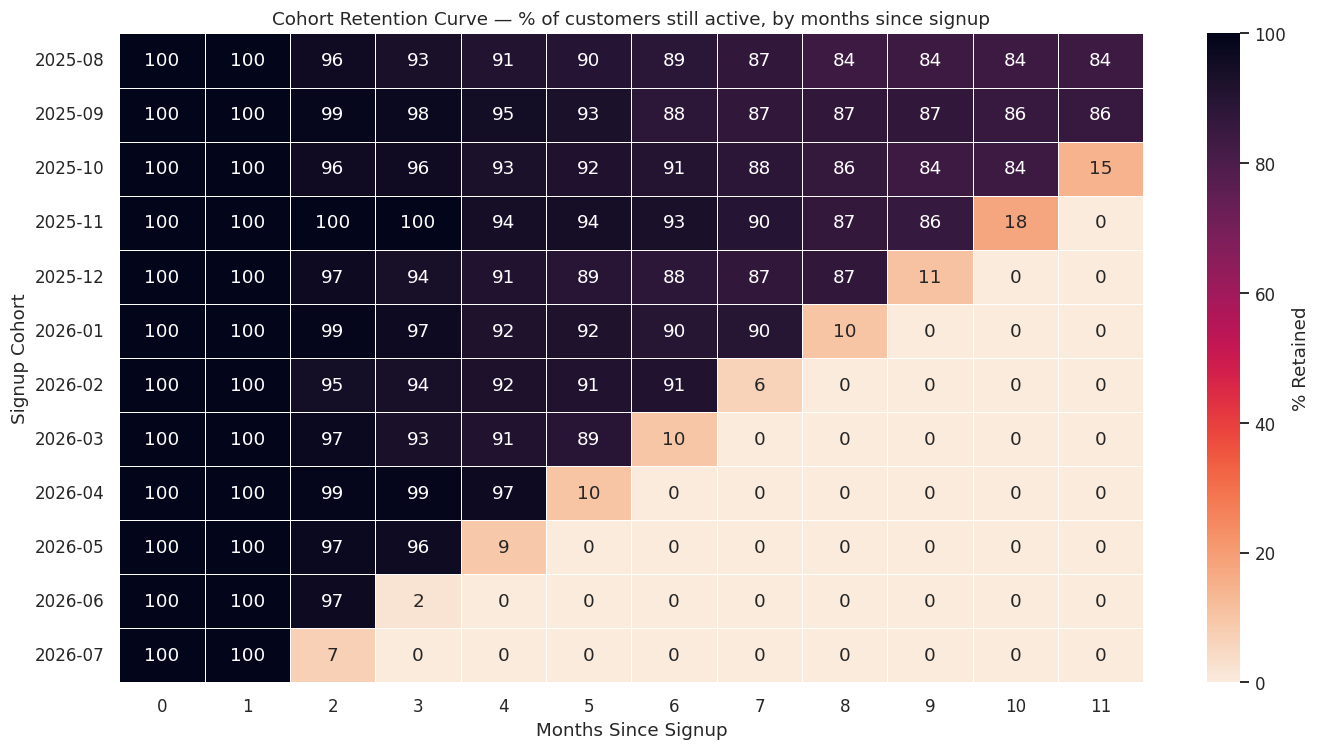

In [4]:
def cohort_retention(df, n_periods=12):
    df = df.copy()
    df["signup_month"] = df["signup_date"].dt.to_period("M")
    cohorts = sorted(df["signup_month"].unique())
    matrix = pd.DataFrame(index=[str(c) for c in cohorts], columns=range(n_periods), dtype=float)
    for cohort in cohorts:
        cdf = df[df["signup_month"] == cohort]
        size = len(cdf)
        for period in range(n_periods):
            still_active = (cdf["tenure_months"] >= period).sum()
            matrix.loc[str(cohort), period] = still_active / size if size else np.nan
    return matrix

cohort_matrix = cohort_retention(df, n_periods=12)

plt.figure(figsize=(13, 7))
sns.heatmap(cohort_matrix.iloc[-12:] * 100, annot=True, fmt=".0f", cmap="rocket_r",
            cbar_kws={"label": "% Retained"}, vmin=0, vmax=100, linewidths=0.4, linecolor="white")
plt.title("Cohort Retention Curve — % of customers still active, by months since signup")
plt.xlabel("Months Since Signup")
plt.ylabel("Signup Cohort")
plt.tight_layout()
plt.show()


**Reading this chart:** each row is a monthly signup cohort; each column is how
many months have passed since signup. The steepest drop for most cohorts happens in the first
1–3 months — a classic sign that onboarding and early engagement, not long-term product fit,
drive most churn.

## 4. Churn Rate by Segment

       plan  churn_rate  customers
0     Basic        0.29       2241
2  Standard        0.20       1763
1   Premium        0.16        996

  contract_type  churn_rate  customers
1       Monthly        0.27       3506
0        Annual        0.14       1494

  acquisition_channel  churn_rate  customers
4         Paid Social        0.30       1011
0           Affiliate        0.23        437
2               Email        0.23        608
1              Direct        0.23        757
3      Organic Search        0.22       1399
5            Referral        0.18        788


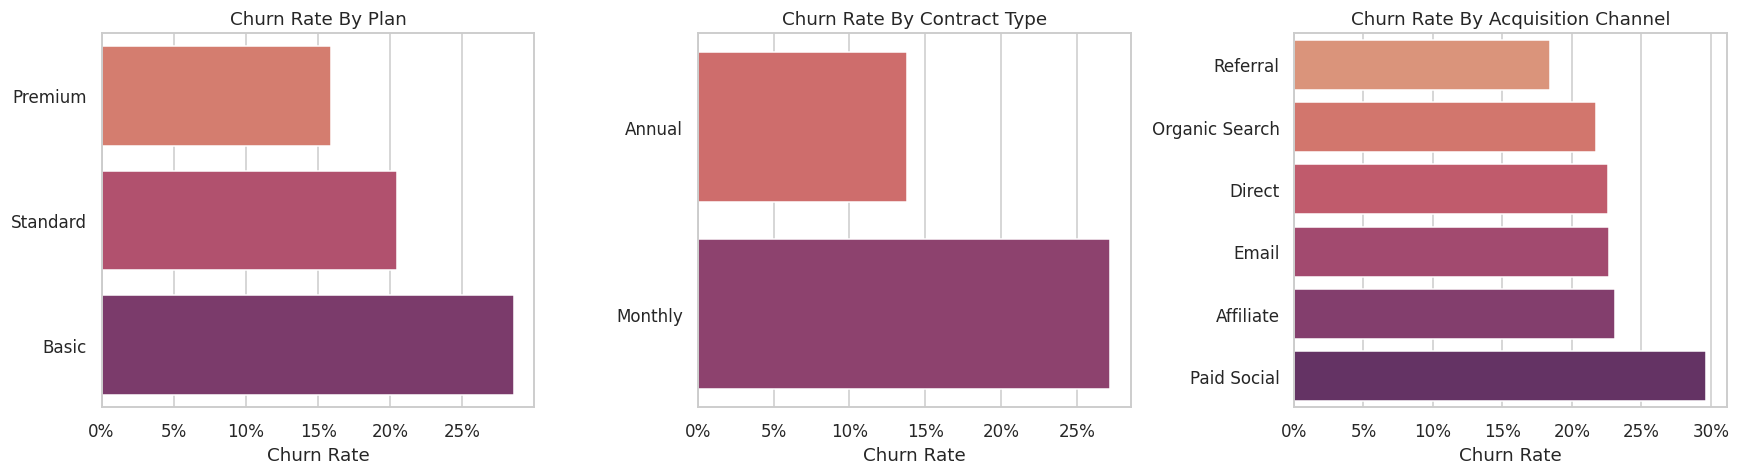

In [5]:
def churn_by_segment(df, col):
    g = df.groupby(col)["churned"].agg(["mean", "count"]).reset_index()
    g.columns = [col, "churn_rate", "customers"]
    return g.sort_values("churn_rate", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title in zip(
    axes,
    ["plan", "contract_type", "acquisition_channel"],
    ["By Plan", "By Contract Type", "By Acquisition Channel"],
):
    seg = churn_by_segment(df, col).sort_values("churn_rate")
    sns.barplot(data=seg, y=col, x="churn_rate", ax=ax, palette="flare")
    ax.set_title(f"Churn Rate {title}")
    ax.set_xlabel("Churn Rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

print(churn_by_segment(df, "plan"))
print()
print(churn_by_segment(df, "contract_type"))
print()
print(churn_by_segment(df, "acquisition_channel"))


**Key read:** Basic-plan and Monthly-contract customers churn at roughly **double**
the rate of Premium/Annual customers, and Paid-Social-acquired customers churn more than any
other channel — a signal of lower-intent traffic from that channel.

## 5. Top Reasons Customers Cancel

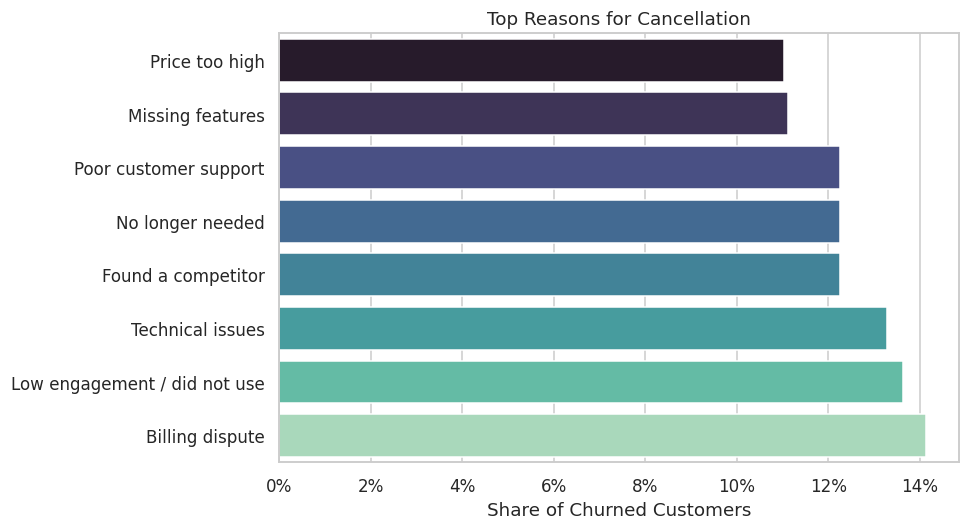

In [6]:
reasons = (df.loc[df.churned == 1, "churn_reason"]
             .value_counts(normalize=True)
             .reset_index())
reasons.columns = ["churn_reason", "share"]
reasons = reasons.sort_values("share")

plt.figure(figsize=(9, 5))
sns.barplot(data=reasons, y="churn_reason", x="share", palette="mako")
plt.title("Top Reasons for Cancellation")
plt.xlabel("Share of Churned Customers")
plt.ylabel("")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()


## 6. Customer Lifetime Value (CLV) by Plan

          avg_clv  median_clv  total_clv  customers
plan                                               
Basic      207.11      169.83 464,131.33       2241
Premium    967.42      955.76 963,553.05        996
Standard   454.94      407.80 802,056.73       1763


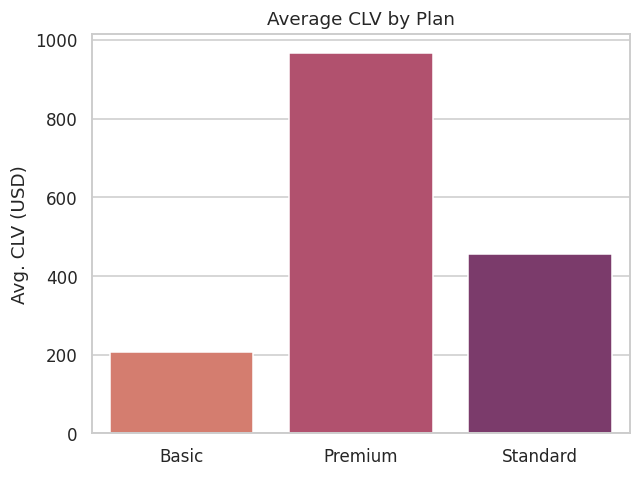

In [7]:
clv = df.groupby("plan")["customer_lifetime_value_usd"].agg(["mean", "median", "sum", "count"])
clv.columns = ["avg_clv", "median_clv", "total_clv", "customers"]
display(clv) if "display" in dir() else print(clv)

plt.figure(figsize=(6, 4.5))
sns.barplot(data=clv.reset_index(), x="plan", y="avg_clv", palette="flare")
plt.title("Average CLV by Plan")
plt.ylabel("Avg. CLV (USD)")
plt.xlabel("")
plt.tight_layout()
plt.show()


## 7. Churn Drivers

tenure_months          -0.53
nps_score              -0.16
monthly_price_usd      -0.09
avg_logins_per_month   -0.07
support_tickets         0.07
age                    -0.01
Name: churned, dtype: float64


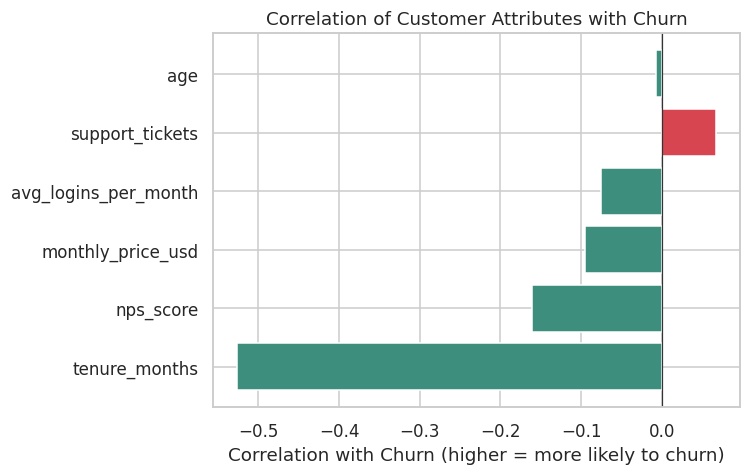

In [8]:
numeric_cols = ["support_tickets", "nps_score", "avg_logins_per_month",
                 "age", "monthly_price_usd", "tenure_months"]
drivers = df[numeric_cols + ["churned"]].corr()["churned"].drop("churned")
drivers = drivers.sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(7, 4.5))
colors = ["#D64550" if v > 0 else "#3E8E7E" for v in drivers.values]
plt.barh(drivers.index, drivers.values, color=colors)
plt.axvline(0, color="#333", lw=0.8)
plt.title("Correlation of Customer Attributes with Churn")
plt.xlabel("Correlation with Churn (higher = more likely to churn)")
plt.tight_layout()
plt.show()

print(drivers)


**Note:** correlation gives a fast, interpretable read on direction and rough
strength. A production version of this analysis would fit a logistic regression or gradient-
boosted model and rank drivers with SHAP values to capture interactions (e.g. low engagement
*combined with* a support ticket is riskier than either alone) — noted here as a natural
next step.

## 8. Key Findings & Recommendations

**Findings**
- Overall churn rate is **~23%**, with **~\$130K** in CLV lost to churn in this dataset.
- Churn is heavily front-loaded: most cancellations happen in a customer's **first 1–3 months**.
- **Basic plan** and **Monthly contracts** churn roughly **2x** more than Premium/Annual.
- **Paid Social** is the highest-churn acquisition channel; **Referral** and **Direct** are the
  stickiest.
- The single strongest predictor of *staying* is **tenure itself** — customers who make it past
  the early danger zone are much more likely to stick around — followed by **NPS score** and
  **login frequency**.
- **Billing disputes, low engagement, and technical issues** together account for over 40% of
  stated cancellation reasons — all addressable operationally.

**Recommendations**
1. **Fix the first 90 days.** Build a structured onboarding flow (setup checklist, early
   check-ins, a "getting value" milestone) targeted at Basic-plan and Monthly-contract
   customers, who are both cheapest to lose and most at risk.
2. **Proactive win-back for low engagement.** Trigger a re-engagement campaign for any customer
   with fewer than 4 logins/month in their first two months.
3. **Audit the billing experience.** Billing disputes are a top-3 stated churn reason and are
   usually a fixable process issue, not a product one.
4. **Rebalance acquisition spend.** Paid Social drives volume but the highest churn; shifting
   budget toward Referral/Direct (or adding stronger qualification to Paid Social) should raise
   blended retention without cutting total signups much.
5. **Incentivize annual contracts** for Standard/Premium customers already showing healthy
   engagement — locking in tenure early compounds retention gains.
